# DINO-WM Results

Single posthoc results notebook (CPU is enough): aggregates every run directory under the Drive log root into `_summary/summary.csv` and renders all tables, figures, and planning videos inline. It never starts training or planning.

Sections: run summary (all environments) → PointMaze training and transfer comparison → planning diagnostics and videos → Push-T (empty until those runs exist).

In [13]:
from pathlib import Path
import csv
import os
import subprocess
import sys

# Locate the repo: works from local Jupyter (cwd = repo or notebooks/) and
# from Colab, where the notebook's cwd is /content and the repo is the
# checkout made by notebook 02's clone cell.
# The kernel can be left inside a deleted directory when notebook 02
# re-clones the repo (rm -rf + clone); recover before probing paths.
try:
    cwd = Path.cwd()
except (FileNotFoundError, OSError):
    os.chdir('/content' if Path('/content').exists() else Path.home())
    cwd = Path.cwd()
candidates = [cwd, cwd.parent, Path('/content/World_Models_LAS')]
REPO = next((p for p in candidates if (p / 'src' / 'wm_poc').is_dir()), None)
if REPO is None:
    raise RuntimeError(
        'World_Models_LAS repo not found (looked in cwd and /content/World_Models_LAS). '
        'Run the clone cell at the top of notebook 02 first.'
    )
os.chdir(REPO)
if str(REPO / 'src') not in sys.path:
    sys.path.insert(0, str(REPO / 'src'))

SUMMARY_ROOT = Path(os.environ.get('DINO_LOG_ROOT', '/content/drive/MyDrive/wm_poc/logs/dino_wm'))
SUMMARY_DIR = SUMMARY_ROOT / '_summary'
SUMMARY_CSV = SUMMARY_DIR / 'summary.csv'
subprocess.run(['python', 'scripts/dino_wm/summarize_runs.py', '--root', str(SUMMARY_ROOT), '--out', str(SUMMARY_DIR)], check=False)


def read_summary(env_filter=None):
    rows = []
    if SUMMARY_CSV.exists():
        with SUMMARY_CSV.open(newline='', encoding='utf-8') as f:
            rows = list(csv.DictReader(f))
    if env_filter is not None:
        kept = [row for row in rows if row.get('env') in env_filter]
        if rows and not kept:
            print(f'No rows for env in {sorted(env_filter)}; envs present: {sorted({r.get("env", "") for r in rows})}')
        return kept
    return rows


def show_table(rows, columns):
    if not rows:
        print('No runs found yet.')
        return
    try:
        import pandas as pd
        frame = pd.DataFrame(rows)
        present = [col for col in columns if col in frame.columns]
        display(frame[present])
    except Exception:
        present = [col for col in columns if any(r.get(col) not in (None, '') for r in rows)]
        widths = {col: max(len(col), *(len(str(r.get(col, ''))) for r in rows)) for col in present}
        print('  '.join(col.ljust(widths[col]) for col in present))
        for row in rows:
            print('  '.join(str(row.get(col, '')).ljust(widths[col]) for col in present))


def show_image(path):
    from IPython.display import Image, display
    path = Path(path)
    if path.is_file():
        display(Image(filename=str(path)))
    else:
        print(f'Not generated (missing inputs): {path}')


def existing_run_dirs(names):
    return [SUMMARY_ROOT / name for name in names if (SUMMARY_ROOT / name).is_dir()]

print(f'Summary CSV: {SUMMARY_CSV}')

Summary CSV: /content/drive/MyDrive/wm_poc/logs/dino_wm/_summary/summary.csv


## Run summary (all environments)

In [14]:
rows = read_summary()
show_table(rows, ['run_name', 'env', 'mode', 'completed', 'timed_out', 'failed', 'train_wall_minutes',
                  'plan_wall_minutes', 'best_epoch', 'final_val_loss_pred_hstep', 'best_success_rate'])

,run_name,env,mode,completed,timed_out,failed,train_wall_minutes,plan_wall_minutes,best_epoch,final_val_loss_pred_hstep,best_success_rate
0,pointmaze_full_nodecoder_t4_fp16_b32_stride2_s...,point_maze,scratch,True,False,False,10.816666666666666,47.3,,,0.26
1,pointmaze_lowdata_finetune_a100_seed0,point_maze,finetune,False,False,True,11.9,47.03333333333333,20,0.0116,0.34
2,pointmaze_lowdata_scratch_a100_seed0,point_maze,scratch,True,False,False,0.6166666666666667,47.4,30,0.0214,0.12
3,pointmaze_oom_safe_seed0,point_maze,scratch,True,False,False,59.9,,2,1.3866,
4,pointmaze_scratch_a100_seed0,point_maze,scratch,False,False,True,0.5,0.4,,,
5,smoke_pointmaze_latent_seed0,point_maze,smoke,True,False,False,0.6166666666666667,0.8166666666666667,,,0.0
6,smoke_pointmaze_seed0,point_maze,smoke,True,False,False,4.816666666666666,0.7833333333333333,7,1.9019,0.0


## PointMaze: training loss curves

Solid lines are validation loss, dashed lines training loss, parsed from the per-epoch summary upstream logs to `stdout.log` (all rotated generations are merged; runs whose early logs predate the lossless-rotation fix may start at a later epoch).

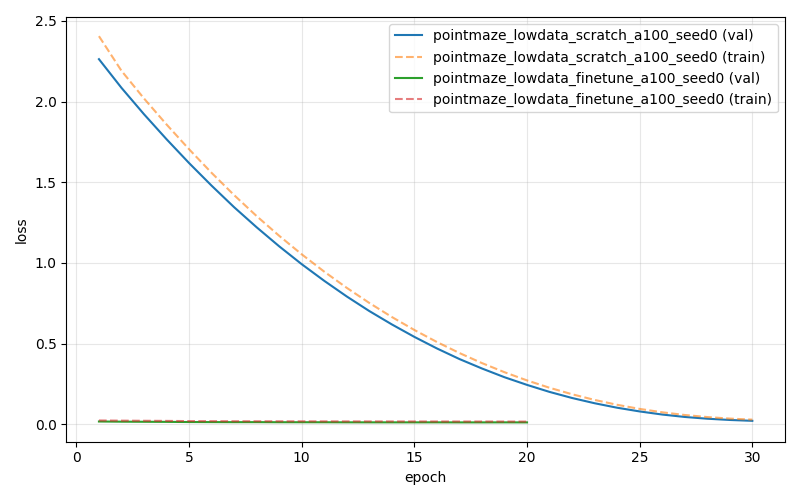

In [15]:
from wm_poc.dino_wm.visualization import plot_training_loss_curves

run_dirs = existing_run_dirs([
    'pointmaze_full_nodecoder_bf16_a100_b32_seed0',
    'pointmaze_full_nodecoder_t4_fp16_b32_stride2_seed0',
    'pointmaze_lowdata_scratch_a100_seed0',
    'pointmaze_lowdata_finetune_a100_seed0',
])
if run_dirs:
    out = SUMMARY_DIR / 'pointmaze_training_curves.png'
    plot_training_loss_curves(run_dirs, out)
    show_image(out)
else:
    print('No pointmaze run directories found yet.')

## PointMaze: planning success rates

Smoke and diagnostic runs are excluded; with `n_evals=50` the 95% interval is roughly ±0.13, so treat sub-0.15 gaps as noise.

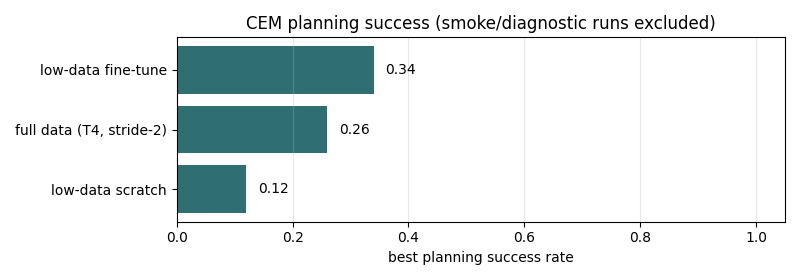

In [16]:
from wm_poc.dino_wm.visualization import plot_planning_success

if SUMMARY_CSV.exists():
    out = SUMMARY_DIR / 'pointmaze_wall_success.png'
    plot_planning_success(SUMMARY_CSV, out)
    show_image(out)
else:
    print('No summary CSV available yet.')

## PointMaze: scratch vs fine-tune (low-data transfer)

Final validation h-step loss for the low-data runs: blue = scratch baseline, orange = fine-tuned from the full run's checkpoint.

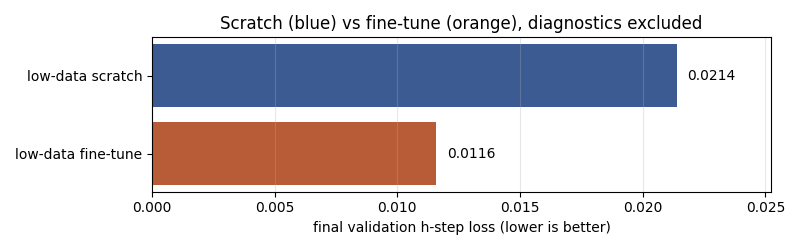

In [17]:
from wm_poc.dino_wm.visualization import plot_scratch_vs_finetune
if SUMMARY_CSV.exists():
    out = SUMMARY_DIR / 'pointmaze_scratch_vs_finetune.png'
    plot_scratch_vs_finetune(SUMMARY_CSV, out)
    show_image(out)
else:
    print('No summary CSV available yet.')

## Planning results per run

Final evaluations parsed from each run's `planning/*/logs.json` (written by upstream `plan.py`), deduplicated across relaunched attempts. The planner-ablation subset from the wrapper summary follows.

In [18]:
import json

try:
    import pandas as pd
except Exception as exc:  # binary-incompatible numpy/pandas (e.g. after the DINO-WM deps install)
    pd = None
    print(f'pandas is unavailable or binary-incompatible in this runtime ({exc}); '
          'skipping the planning table. Run this notebook in a fresh runtime to view it. '
          'Raw per-episode logs remain under <run>/planning/<planner>/logs.json.')

if pd is not None:
    run_dirs = sorted(p for p in SUMMARY_ROOT.iterdir() if p.is_dir() and not p.name.startswith('_')) if SUMMARY_ROOT.exists() else []
    records = []
    for run_dir in run_dirs:
        for logs_path in sorted(run_dir.glob('planning/*/logs.json')):
            for line in logs_path.read_text(encoding='utf-8', errors='replace').splitlines():
                if not line.strip():
                    continue
                entry = {k.replace('final_eval/', '').replace('plan_0/', ''): v for k, v in json.loads(line).items()}
                entry['run'] = run_dir.name
                entry['planner'] = logs_path.parent.name
                records.append(entry)

    frame = pd.DataFrame(records).drop_duplicates() if records else pd.DataFrame()
    # Final evaluations have no 'step'; per-iteration CEM logs do.
    final = frame[frame.get('step').isna()] if 'step' in frame.columns else frame
    iters = frame[frame.get('step').notna()] if 'step' in frame.columns else pd.DataFrame()
    # Relaunched attempts append duplicate iteration blocks; keep the latest per (run, step).
    if len(iters):
        iters = iters.groupby(['run', 'planner', 'step'], as_index=False).last()

    if len(final):
        lead = [c for c in ['run', 'planner', 'success_rate', 'mean_state_dist', 'mean_div_visual_emb'] if c in final.columns]
        display(final[lead + [c for c in final.columns if c not in lead and not final[c].isna().all()]])
    else:
        print('No planning evaluations found yet; run a planning eval first.')

,run,planner,success_rate,mean_state_dist,mean_div_visual_emb,mean_visual_dist,mean_proprio_dist,mean_div_proprio_emb
14,pointmaze_full_nodecoder_t4_fp16_b32_stride2_s...,cem,0.260,1.018441,334.466217,0.565913,0.426286,9.100231
25,pointmaze_full_nodecoder_t4_fp16_b32_stride2_s...,cem,0.230,0.991106,702.618225,0.570158,0.409819,18.098629
36,pointmaze_lowdata_finetune_a100_seed0,cem,0.340,0.997712,378.141846,0.548234,0.426114,8.247719
47,pointmaze_lowdata_finetune_a100_seed0,cem,0.275,0.928829,705.208496,0.554890,0.394463,17.073845
58,pointmaze_lowdata_scratch_a100_seed0,cem,0.120,1.022048,393.969788,0.571232,0.432331,10.077181
80,pointmaze_lowdata_scratch_a100_seed0,cem,0.100,1.003393,786.424438,0.565826,0.430862,20.632280
83,smoke_pointmaze_latent_seed0,cem,0.000,1.358037,631.629639,0.554133,0.551576,3.815320
107,smoke_pointmaze_latent_seed0,cem,0.000,1.358038,631.629456,0.554133,0.551576,3.814911
110,smoke_pointmaze_seed0,cem,0.000,1.358037,588.589111,0.554133,0.551576,2.592546
113,smoke_pointmaze_seed0,cem,0.000,1.358037,577.805359,0.554133,0.551576,2.562437


In [19]:
planner_csv = SUMMARY_DIR / 'planner_ablation.csv'
rows = []
if planner_csv.exists():
    with planner_csv.open(newline='', encoding='utf-8') as f:
        rows = list(csv.DictReader(f))
if rows:
    show_table(rows, ['run_name', 'env', 'best_success_rate', 'final_goal_latent_distance', 'plan_wall_minutes', 'timed_out', 'failed'])
else:
    print('No planner-ablation runs yet (the CEM-vs-GD config has not been run); the tables above cover the standard CEM evals.')

No planner-ablation runs yet (the CEM-vs-GD config has not been run); the tables above cover the standard CEM evals.


## CEM optimization progress

Upstream logs the planner's state after every CEM iteration (`plan_0/*` entries in `logs.json`): success rate of the current best plans, mean state distance to the goal, and the divergence between imagined and executed latent embeddings. Rising success / falling distances across iterations means the planner is actually optimizing in the model's latent space.

In [20]:
import json

try:
    import pandas as pd
except Exception as exc:  # binary-incompatible numpy/pandas (e.g. after the DINO-WM deps install)
    pd = None
    print(f'pandas is unavailable or binary-incompatible in this runtime ({exc}); '
          'skipping the planning table. Run this notebook in a fresh runtime to view it. '
          'Raw per-episode logs remain under <run>/planning/<planner>/logs.json.')

if pd is not None:
    run_dirs = sorted(p for p in SUMMARY_ROOT.iterdir() if p.is_dir() and not p.name.startswith('_')) if SUMMARY_ROOT.exists() else []
    records = []
    for run_dir in run_dirs:
        for logs_path in sorted(run_dir.glob('planning/*/logs.json')):
            for line in logs_path.read_text(encoding='utf-8', errors='replace').splitlines():
                if not line.strip():
                    continue
                entry = {k.replace('final_eval/', '').replace('plan_0/', ''): v for k, v in json.loads(line).items()}
                entry['run'] = run_dir.name
                entry['planner'] = logs_path.parent.name
                records.append(entry)

    frame = pd.DataFrame(records).drop_duplicates() if records else pd.DataFrame()
    # Final evaluations have no 'step'; per-iteration CEM logs do.
    final = frame[frame.get('step').isna()] if 'step' in frame.columns else frame
    iters = frame[frame.get('step').notna()] if 'step' in frame.columns else pd.DataFrame()
    # Relaunched attempts append duplicate iteration blocks; keep the latest per (run, step).
    if len(iters):
        iters = iters.groupby(['run', 'planner', 'step'], as_index=False).last()

    if len(final):
        lead = [c for c in ['run', 'planner', 'success_rate', 'mean_state_dist', 'mean_div_visual_emb'] if c in final.columns]
        display(final[lead + [c for c in final.columns if c not in lead and not final[c].isna().all()]])
    else:
        print('No planning evaluations found yet; run a planning eval first.')

,run,planner,success_rate,mean_state_dist,mean_div_visual_emb,mean_visual_dist,mean_proprio_dist,mean_div_proprio_emb
14,pointmaze_full_nodecoder_t4_fp16_b32_stride2_s...,cem,0.260,1.018441,334.466217,0.565913,0.426286,9.100231
25,pointmaze_full_nodecoder_t4_fp16_b32_stride2_s...,cem,0.230,0.991106,702.618225,0.570158,0.409819,18.098629
36,pointmaze_lowdata_finetune_a100_seed0,cem,0.340,0.997712,378.141846,0.548234,0.426114,8.247719
47,pointmaze_lowdata_finetune_a100_seed0,cem,0.275,0.928829,705.208496,0.554890,0.394463,17.073845
58,pointmaze_lowdata_scratch_a100_seed0,cem,0.120,1.022048,393.969788,0.571232,0.432331,10.077181
80,pointmaze_lowdata_scratch_a100_seed0,cem,0.100,1.003393,786.424438,0.565826,0.430862,20.632280
83,smoke_pointmaze_latent_seed0,cem,0.000,1.358037,631.629639,0.554133,0.551576,3.815320
107,smoke_pointmaze_latent_seed0,cem,0.000,1.358038,631.629456,0.554133,0.551576,3.814911
110,smoke_pointmaze_seed0,cem,0.000,1.358037,588.589111,0.554133,0.551576,2.592546
113,smoke_pointmaze_seed0,cem,0.000,1.358037,577.805359,0.554133,0.551576,2.562437


## Planning videos

Each planning eval records the executed plan as `output_final_<episode>_<success|failure>.mp4`. A few are embedded per run; the full set stays in the listed directories.

In [21]:
from IPython.display import HTML, Video, display

MAX_VIDEOS_PER_RUN = 4
shown_any = False
for run_dir in run_dirs:
    videos = sorted(run_dir.glob('planning/*/output_final_*.mp4'))
    if not videos:
        continue
    successes = [v for v in videos if v.stem.endswith('success')]
    failures = [v for v in videos if v.stem.endswith('failure')]
    picks = (successes[: MAX_VIDEOS_PER_RUN // 2] + failures[: MAX_VIDEOS_PER_RUN // 2]) or videos[:MAX_VIDEOS_PER_RUN]
    display(HTML(f'<h4>{run_dir.name} ({len(successes)} success / {len(failures)} failure videos)</h4>'))
    for video in picks:
        display(HTML(f'<b>{video.name}</b>'))
        display(Video(str(video), embed=True, width=320))
    shown_any = True
if not shown_any:
    print('No planning videos found yet; run a planning evaluation first.')

## Artifact directories

In [22]:
for run_dir in run_dirs:
    for artifact_dir in ['planning', 'figures', 'videos']:
        path = run_dir / artifact_dir
        if path.exists():
            print(path)

/content/drive/MyDrive/wm_poc/logs/dino_wm/pointmaze_full_nodecoder_bf16_a100_b32_seed0/planning
/content/drive/MyDrive/wm_poc/logs/dino_wm/pointmaze_full_nodecoder_bf16_a100_b32_seed0/figures
/content/drive/MyDrive/wm_poc/logs/dino_wm/pointmaze_full_nodecoder_bf16_a100_b32_seed0/videos
/content/drive/MyDrive/wm_poc/logs/dino_wm/pointmaze_full_nodecoder_bf16_seed0/planning
/content/drive/MyDrive/wm_poc/logs/dino_wm/pointmaze_full_nodecoder_bf16_seed0/figures
/content/drive/MyDrive/wm_poc/logs/dino_wm/pointmaze_full_nodecoder_bf16_seed0/videos
/content/drive/MyDrive/wm_poc/logs/dino_wm/pointmaze_full_nodecoder_t4_fp16_b32_stride2_seed0/planning
/content/drive/MyDrive/wm_poc/logs/dino_wm/pointmaze_full_nodecoder_t4_fp16_b32_stride2_seed0/figures
/content/drive/MyDrive/wm_poc/logs/dino_wm/pointmaze_full_nodecoder_t4_fp16_b32_stride2_seed0/videos
/content/drive/MyDrive/wm_poc/logs/dino_wm/pointmaze_lowdata_finetune_a100_seed0/planning
/content/drive/MyDrive/wm_poc/logs/dino_wm/pointmaze_lo

## Push-T (scratch, fine-tune, causal-mask ablation)

Empty until Push-T runs exist. Note: Push-T currently trains on the online image path (the latent cache only supports point_maze).

In [23]:
rows = read_summary(env_filter={'pusht_noise'})
show_table(rows, ['run_name', 'mode', 'completed', 'timed_out', 'failed', 'train_wall_minutes', 'plan_wall_minutes', 'best_epoch', 'final_val_loss_pred_hstep', 'best_success_rate', 'final_goal_latent_distance'])

No rows for env in ['pusht_noise']; envs present: ['point_maze']
No runs found yet.


In [ ]:
# Optional Push-T training curves. Push-T is future work for the DINO-WM track
# (it needs a video-backed latent cache; see the report conclusion) and is NOT
# part of this report, so the helper that resolves its run directories may be
# undefined. Guard on that rather than failing the notebook.
if 'existing_pusht_run_dirs' in globals():
    from wm_poc.dino_wm.visualization import plot_training_loss_curves
    pusht_run_dirs = existing_pusht_run_dirs([
        'pusht_1k_scratch_a100_seed0',
        'pusht_1k_finetune_a100_seed0',
        'pusht_causal_mask_true_a100_seed0',
        'pusht_causal_mask_false_a100_seed0',
    ])
    if pusht_run_dirs:
        out = SUMMARY_DIR / 'pusht_training_curves.png'
        plot_training_loss_curves(pusht_run_dirs, out)
        show_image(out)
    else:
        print('No Push-T run directories found yet.')
else:
    print('Push-T is future work for this track and not part of this report; skipping.')

Push-T is future work for this track and not part of this report; skipping.
